# TB Chest X-ray Classifier (MobileNetV2)

**Revision notes (fixes applied):**
1. **One split, one model.** The notebook used to build two different train/val splits and reused the same `model` object across both, which meant the "final" model had already trained on images that later ended up in what was supposed to be the held-out test set. Now there is exactly one split (train/val/test), created once, and the model is trained fresh on it.
2. **Threshold re-derived, not copy-pasted.** The classification threshold is now picked programmatically from the validation set every time the model changes (baseline vs. fine-tuned), instead of reusing `0.3` from an earlier run.
3. Data path is now a single clearly-labeled config variable with a sanity check.
4. Training now plots loss/accuracy curves so over/underfitting is visible.
5. `EarlyStopping` + `ModelCheckpoint` added so training stops at the best epoch instead of whatever epoch count was guessed, and the best weights are saved to disk.

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [2]:
# --- Fix (small #2): single clearly-labeled config block for the data location ---
# Point this at the folder that contains the "Normal" and "Tuberculosis" subfolders.
# (Small thing to remember: this path is still local to your machine. If you ever share
# this notebook or move it to Kaggle/Colab, this is the one line you need to change.)
data_dir = "C:/Users/mboug/Desktop/tuberculosis/TB_Chest_Radiography_Database"
NORMAL_DIR = os.path.join(data_dir, "Normal")
TB_DIR = os.path.join(data_dir, "Tuberculosis")

assert os.path.isdir(NORMAL_DIR) and os.path.isdir(TB_DIR), (
    f"Couldn't find Normal/Tuberculosis folders under {data_dir}. "
    "Update data_dir above to point at your local copy of the dataset."
)

img_size = (224, 224)
batch_size = 16
SEED = 42

## 2. EDA

In [3]:
normal_images = len(os.listdir(NORMAL_DIR))
tb_images = len(os.listdir(TB_DIR))
normal_images, tb_images

(3500, 700)

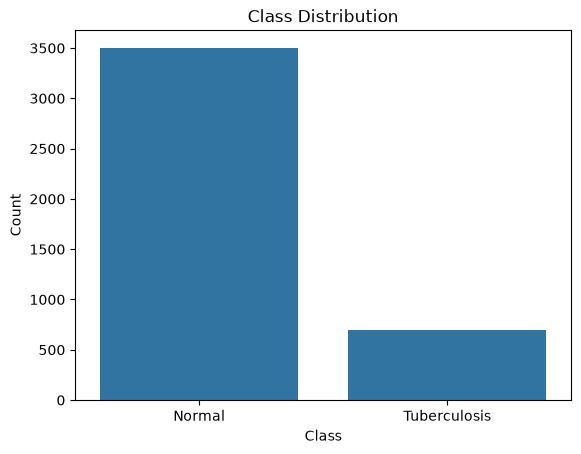

In [4]:
class_counts = pd.DataFrame({
    'Class': ['Normal', 'Tuberculosis'],
    'Count': [normal_images, tb_images]
})
sns.barplot(x='Class', y='Count', data=class_counts)
plt.title('Class Distribution')
plt.show()

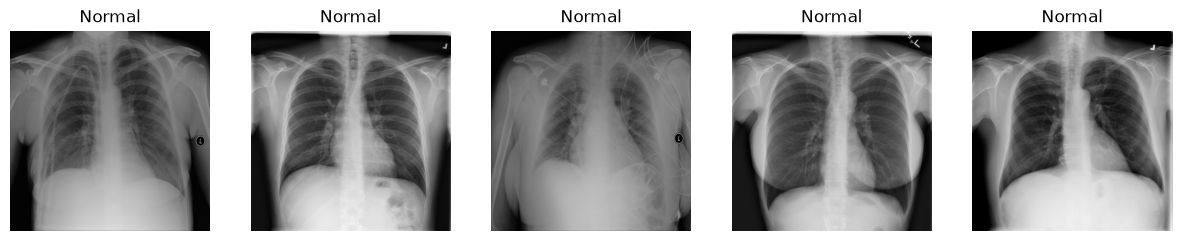

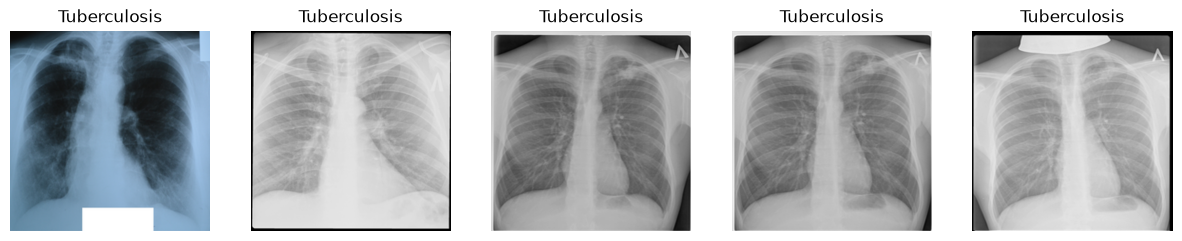

In [5]:
from PIL import Image

def show_samples(folder, title, n=5):
    image_files = os.listdir(folder)[:n]

    plt.figure(figsize=(15, 4))
    for i, image_name in enumerate(image_files):
        img_path = os.path.join(folder, image_name)
        img = Image.open(img_path)

        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(title)
    plt.show()

show_samples(NORMAL_DIR, 'Normal')
show_samples(TB_DIR, 'Tuberculosis')

## 3. Train / Validation / Test split

**Fix (big #1 and #2).** This is now the *only* split built in the whole notebook. Everything downstream — the baseline model, the fine-tuned model, both threshold choices, both test evaluations — uses this exact `train_df` / `val_df` / `test_df`. Because the split happens once and `test_df` is never touched by training, there's no way for test images to leak into training data through an earlier run.

In [6]:
filepaths = []
labels = []

for class_name in ["Normal", "Tuberculosis"]:
    class_dir = os.path.join(data_dir, class_name)
    for filename in os.listdir(class_dir):
        filepaths.append(os.path.join(class_dir, filename))
        labels.append(class_name)

df = pd.DataFrame({
    'filepath': filepaths,
    'label': labels
})

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=SEED
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label_num"] = (train_df["label"] == "Tuberculosis").astype(np.float32)
val_df["label_num"] = (val_df["label"] == "Tuberculosis").astype(np.float32)
test_df["label_num"] = (test_df["label"] == "Tuberculosis").astype(np.float32)

print(len(train_df), len(val_df), len(test_df))
print(train_df['label'].value_counts())
print(val_df['label'].value_counts())
print(test_df['label'].value_counts())

3360 420 420
label
Normal          2800
Tuberculosis     560
Name: count, dtype: int64
label
Normal          350
Tuberculosis     70
Name: count, dtype: int64
label
Normal          350
Tuberculosis     70
Name: count, dtype: int64


## 4. Preprocessing pipeline

In [8]:
def decode_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, img_size)

    image = tf.ensure_shape(image, [224, 224, 3])

    label = tf.cast(label, tf.float32)
    label = tf.reshape(label, [1])
    label = tf.ensure_shape(label, [1])

    return image, label

In [9]:
def make_dataset(dataframe, shuffle=False):
    filepaths = dataframe["filepath"].astype(str).values
    labels = dataframe["label_num"].to_numpy(dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

## 5. Data Augmentation

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

## 6. Handling Class Imbalance

In [11]:
train_labels_numeric = (train_df['label'] == "Tuberculosis").astype(int)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_labels_numeric
)

class_weights_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weights_dict)

{0: np.float64(0.6), 1: np.float64(3.0)}


## 7. Model

**Fix (big #1).** Model construction is wrapped in a function so it can be built completely fresh, with no leftover weights from a previous run. `base_model` is returned alongside `model` so we can reference it later when unfreezing layers for fine-tuning.

In [12]:
def build_model():
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

## 8. Baseline training (frozen base)

**Fix (small #4).** `EarlyStopping` stops training once `val_loss` stops improving and restores the best-epoch weights, so we no longer have to guess an epoch count. `ModelCheckpoint` saves the best weights to disk as a backup.

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_head_model.keras", monitor="val_loss", save_best_only=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Epoch 1/15


c:\Users\mboug\Desktop\tuberculosis\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


210/210 ━━━━━━━━━━━━━━━━━━━━ 82s 361ms/step - accuracy: 0.5676 - loss: 0.7337 - precision: 0.2084 - recall: 0.5696 - val_accuracy: 0.8810 - val_loss: 0.3505 - val_precision: 0.9545 - val_recall: 0.3000
Epoch 2/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 77s 368ms/step - accuracy: 0.7652 - loss: 0.5315 - precision: 0.3887 - recall: 0.7143 - val_accuracy: 0.9167 - val_loss: 0.2601 - val_precision: 1.0000 - val_recall: 0.5000
Epoch 3/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 80s 382ms/step - accuracy: 0.8286 - loss: 0.4211 - precision: 0.4910 - recall: 0.7768 - val_accuracy: 0.9262 - val_loss: 0.2135 - val_precision: 1.0000 - val_recall: 0.5571
Epoch 4/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 77s 367ms/step - accuracy: 0.8693 - loss: 0.3553 - precision: 0.5753 - recall: 0.8250 - val_accuracy: 0.9333 - val_loss: 0.1867 - val_precision: 1.0000 - val_recall: 0.6000
Epoch 5/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 82s 367ms/step - accuracy: 0.8857 - loss: 0.3113 - precision: 0.6122 - recall: 0.8571 - val_accuracy: 0.9286 - val_loss

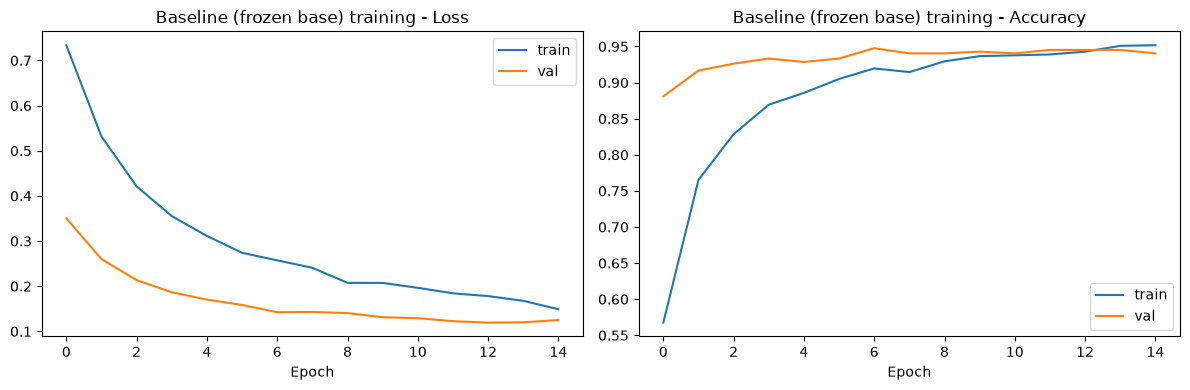

In [14]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history, "Baseline (frozen base) training")

## 9. Choosing a threshold (on the validation set)

**Fix (big #2).** Instead of reusing a threshold picked on a different split, we derive it here, from this model's predictions on this validation set, by finding the threshold that maximizes F1. This cell is reused as-is after fine-tuning, so the threshold always matches the model that's actually being evaluated.

In [15]:
def get_probs(dataset, model):
    y_true, y_probs = [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().flatten())
        y_probs.extend(probs.flatten())
    return np.array(y_true), np.array(y_probs)

def pick_threshold(y_true, y_probs):
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
    best_idx = np.argmax(f1_scores[:-1])  # last precision/recall point has no matching threshold
    return thresholds[best_idx], precision, recall, thresholds

Selected threshold (max F1 on validation set): 0.174


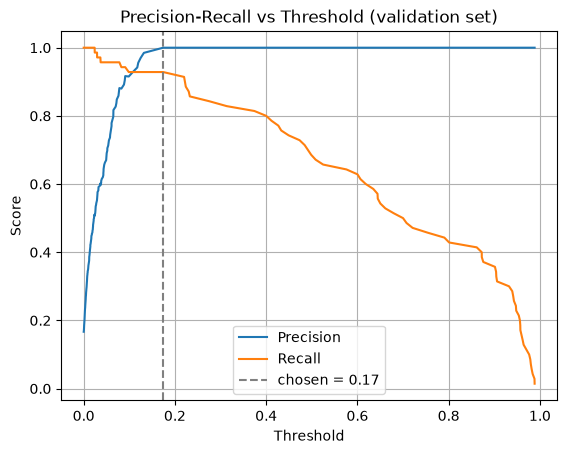

In [16]:
y_true_val, y_probs_val = get_probs(val_ds, model)
threshold, precision, recall, thresholds = pick_threshold(y_true_val, y_probs_val)
print(f"Selected threshold (max F1 on validation set): {threshold:.3f}")

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(threshold, color="gray", linestyle="--", label=f"chosen = {threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold (validation set)")
plt.legend()
plt.grid(True)
plt.show()

If you have a specific reason to prefer higher recall over max-F1 (reasonable for a medical screening task — missing a TB case is worse than a false alarm), you can swap `pick_threshold` for something like "lowest threshold where recall >= 0.9", just make sure you apply the same rule both times (baseline and fine-tuned) so the comparison stays fair.

## 10. Baseline evaluation on the test set

In [17]:
y_true_test, y_probs_test = get_probs(test_ds, model)
y_pred_test = (y_probs_test >= threshold).astype(int)

print(classification_report(y_true_test, y_pred_test, target_names=["Normal", "Tuberculosis"]))

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       350
Tuberculosis       0.98      0.91      0.95        70

    accuracy                           0.98       420
   macro avg       0.98      0.96      0.97       420
weighted avg       0.98      0.98      0.98       420



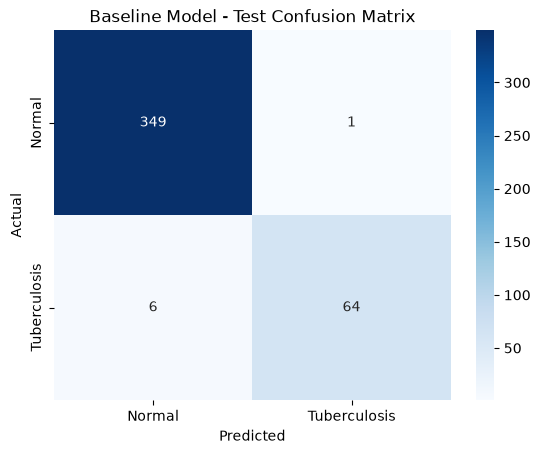

In [18]:
cm = confusion_matrix(y_true_test, y_pred_test)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "Tuberculosis"],
    yticklabels=["Normal", "Tuberculosis"],
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Model - Test Confusion Matrix")
plt.show()

## 11. Fine-tuning

Unfreezing the last 30 layers of MobileNetV2 and continuing training on the **same** train/val split from Section 3 — this is intentional continuation on one consistent split, not a new pipeline, so there's no leakage risk here.

In [19]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [20]:
ft_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_finetuned_model.keras", monitor="val_loss", save_best_only=True),
]

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=ft_callbacks
)

Epoch 1/15


c:\Users\mboug\Desktop\tuberculosis\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


210/210 ━━━━━━━━━━━━━━━━━━━━ 102s 441ms/step - accuracy: 0.8048 - loss: 0.2972 - precision: 0.4592 - recall: 0.9643 - val_accuracy: 0.9690 - val_loss: 0.0883 - val_precision: 1.0000 - val_recall: 0.8143
Epoch 2/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 91s 433ms/step - accuracy: 0.9524 - loss: 0.1401 - precision: 0.7967 - recall: 0.9589 - val_accuracy: 0.9714 - val_loss: 0.0840 - val_precision: 1.0000 - val_recall: 0.8286
Epoch 3/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 145s 446ms/step - accuracy: 0.9661 - loss: 0.1027 - precision: 0.8484 - recall: 0.9696 - val_accuracy: 0.9762 - val_loss: 0.0704 - val_precision: 1.0000 - val_recall: 0.8571
Epoch 4/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 93s 443ms/step - accuracy: 0.9747 - loss: 0.0862 - precision: 0.8900 - recall: 0.9679 - val_accuracy: 0.9762 - val_loss: 0.0785 - val_precision: 1.0000 - val_recall: 0.8571
Epoch 5/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 95s 451ms/step - accuracy: 0.9708 - loss: 0.0777 - precision: 0.8678 - recall: 0.9732 - val_accuracy: 0.9762 - val_lo

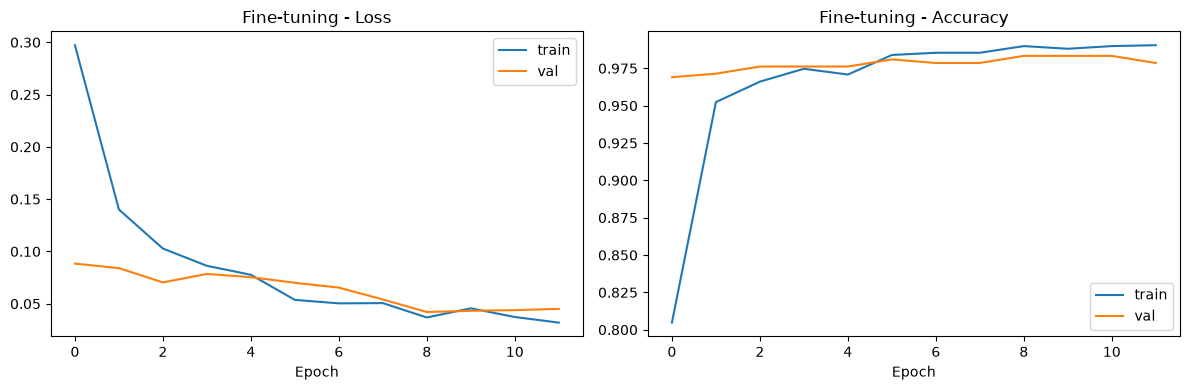

In [21]:
plot_history(fine_tune_history, "Fine-tuning")

## 12. Re-deriving the threshold after fine-tuning

The model changed, so its output probabilities changed too — re-running threshold selection (rather than reusing the baseline's threshold) keeps this fair.

Selected threshold after fine-tuning (max F1 on validation set): 0.057


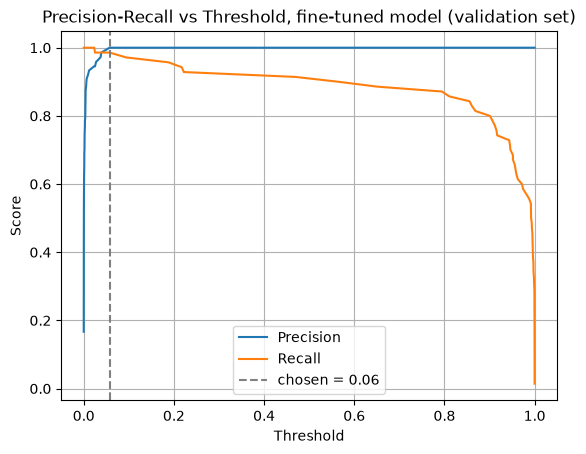

In [22]:
y_true_val, y_probs_val = get_probs(val_ds, model)
threshold, precision, recall, thresholds = pick_threshold(y_true_val, y_probs_val)
print(f"Selected threshold after fine-tuning (max F1 on validation set): {threshold:.3f}")

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(threshold, color="gray", linestyle="--", label=f"chosen = {threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold, fine-tuned model (validation set)")
plt.legend()
plt.grid(True)
plt.show()

## 13. Final evaluation on the test set

In [23]:
y_true_test, y_probs_test = get_probs(test_ds, model)
y_pred_test = (y_probs_test >= threshold).astype(int)

print(classification_report(y_true_test, y_pred_test, target_names=["Normal", "Tuberculosis"]))

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       350
Tuberculosis       1.00      0.94      0.97        70

    accuracy                           0.99       420
   macro avg       0.99      0.97      0.98       420
weighted avg       0.99      0.99      0.99       420



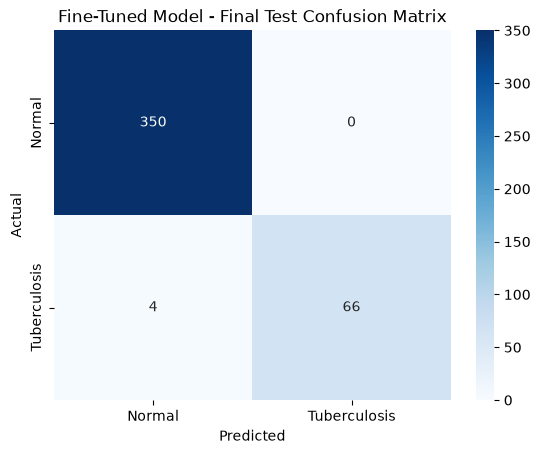

In [24]:
cm = confusion_matrix(y_true_test, y_pred_test)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "Tuberculosis"],
    yticklabels=["Normal", "Tuberculosis"],
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fine-Tuned Model - Final Test Confusion Matrix")
plt.show()